# Mean-Variance Portfolio Optimization

This notebook introduces Mean-Variance (Markowitz) portfolio optimization using NVIDIA's Quantitative Portfolio Optimization framework. We demonstrate step-by-step how to pre-process input data, build the optimization model, solve the problem, and analyze the results.

In particular, we will cover the following:
- **Data Preprocessing** - Calculate daily returns from input price data
- **Model Building** - Build the optimization problem with customizable constraints
- **Solving Optimization** - Call GPU/CPU solvers to solve the quadratic program
- **Results Analysis** - Visualize and evaluate the optimized portfolio


## Table of Contents

0. [Setup](#setup)
   - GPU Check
   - Import Libraries

1. [Introduction to Mean-Variance Optimization](#introduction)
   - Mathematical Formulation

2. [Data Preprocessing](#data-preprocessing)
   - Load Price Data
   - Compute Returns

3. [Build Mean-Variance Problem](#build-problem)
   - Define Parameters
   - Instantiate Optimizer

4. [Solve Optimization](#solve)
   - GPU Solver (cuOpt)
   - CPU Solver Comparison

5. [Analyze Results](#analyze)
   - Portfolio Visualization
   - Performance Metrics


---

## 0. Setup
<a id='setup'></a>

### 0.1 GPU Check


In [1]:
!nvidia-smi

Fri Feb 13 05:52:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    On  |   00000000:1B:00.0 Off |                    0 |
| N/A   30C    P0             77W /  700W |       0MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### 0.2 Import Libraries


In [ ]:
import os
import cvxpy as cp
import numpy as np

from cufolio import mean_variance_optimizer, utils
from cufolio.mean_variance_parameters import MeanVarianceParameters
from cufolio.settings import (
    ApiSettings,
    ReturnsComputeSettings,
)


/home/scratch.phuo_wwfo_1/github/quantitative-portfolio-optimization/.venv-qp/lib/python3.13/site-packages/libcuopt/load.py:82: RuntimeWarning: Failed to load libcuopt library: libcuopt.so. Error: /home/scratch.phuo_wwfo_1/github/quantitative-portfolio-optimization/.venv-qp/lib/python3.13/site-packages/libcuopt/lib64/libcuopt.so: undefined symbol: _ZN3rmm18exec_policy_nosyncC1ENS_16cuda_stream_viewENS_6detail23cccl_async_resource_refIN4cuda2mr3__412resource_refIJNS6_17device_accessibleEEEEEE. Falling back to relying on system loader. cuOpt functionality may be unavailable. This might lead to a generic error such as 'libcuopt.so missing' if the library cannot be found.
  warnings.warn(


ModuleNotFoundError: No module named 'cufolio'

---

<a id='introduction'></a>
## 1. Introduction to Mean-Variance Optimization

Mean-Variance optimization, introduced by Harry Markowitz in 1952, is the foundation of Modern Portfolio Theory. The model captures the risk-return trade-off by maximizing expected return while minimizing portfolio variance.

### Mathematical Formulation

The portfolio variance is computed as:
$$\text{Var}(w) = w^\top \Sigma w$$

where $\Sigma$ is the covariance matrix of asset returns and $w$ is the vector of portfolio weights.

The Mean-Variance optimization problem is formulated as:

\begin{align*}
\text{maximize } \quad &\mu^\top w - \lambda_{\text{risk}} \cdot w^\top \Sigma w\\
\text{subject to} \quad 
& \sum_i w_i + c = 1 \quad \text{(self-financing)}\\
& w_i^{\text{min}} \leq w_i \leq w_i^{\text{max}}, \forall i \quad \text{(concentration)}\\
& c^{\text{min}} \leq c \leq c^{\text{max}} \quad \text{(cash)}\\
& L = \|w\|_1 \leq L^{\text{limit}} \quad \text{(leverage)}\\
& T = \|w - w_{\text{prev}}\|_1 \leq T^{\text{limit}} \quad \text{(turnover)}
\end{align*}

where:
- $\mu$ is the vector of expected returns
- $\lambda_{\text{risk}}$ is the risk aversion parameter
- $w$ is the portfolio weights vector
- $c$ is the cash allocation

This is a **Quadratic Program (QP)** since the objective contains a quadratic term $w^\top \Sigma w$.


---

<a id='data-preprocessing'></a>
## 2. Data Preprocessing

We start with an example using a subset of S&P 500 stocks. We load closing prices and compute daily log-returns.

### 2.1 Load Price Data

#### Disclaimer
*Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.*


In [3]:
# User inputs for S&P 500 example
dataset_name = "sp500"
dataset_format = "csv"
data_path = f"../data/stock_data/{dataset_name}.{dataset_format}"

# Download data if not exists
if not os.path.exists(data_path):
    utils.download_data(data_path)

### 2.2 Compute Returns

We compute log returns and calculate the mean and covariance matrix needed for Mean-Variance optimization.


In [4]:
# Settings for computing returns
returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
regime_dict = {'name': 'recent', 'range':('2022-01-01','2024-01-01')}

# Calculate returns, mean, and covariance
returns_dict = utils.calculate_returns(
    data_path,
    regime_dict,
    returns_compute_settings
)

print(f"Number of assets: {len(returns_dict['tickers'])}")
print(f"Number of observations: {len(returns_dict['returns'])}")
print(f"\nSample tickers: {returns_dict['tickers'][:10]}")
print(f"\nMean returns (first 5): {returns_dict['mean'][:5]}")
print(f"\nCovariance matrix shape: {returns_dict['covariance'].shape}")


Number of assets: 392
Number of observations: 500

Sample tickers: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK']

Mean returns (first 5): [-0.00020888  0.0001351  -0.00039439  0.00102219 -0.00023897]

Covariance matrix shape: (392, 392)


---

<a id='build-problem'></a>
## 3. Build Mean-Variance Problem

### 3.1 Define Optimization Parameters

We define a `MeanVarParameters` object to encapsulate key constraints:

| Parameter | Description |
|-----------|-------------|
| `w_min`, `w_max` | Weight bounds per asset (allows shorting if negative) |
| `c_min`, `c_max` | Cash allocation bounds |
| `L_tar` | Leverage limit (sum of absolute weights) |
| `T_tar` | Turnover limit (optional) |
| `risk_aversion` | Risk aversion parameter λ |
| `var_limit` | Hard variance limit (optional) |


In [5]:
# Define Mean-Variance optimization parameters
mean_variance_params = MeanVarianceParameters(
    w_min={"NVDA": 0.1, "others": -0.3},  # Min weights (allows shorting)
    w_max={"NVDA": 0.6, "others": 0.2},   # Max weights per asset
    c_min=0.0,                             # Minimum cash allocation
    c_max=0.2,                             # Maximum cash allocation
    L_tar=1.6,                             # Leverage constraint
    T_tar=None,                            # No turnover constraint
    risk_aversion=1.0,                     # Risk aversion level
    var_limit=None,                        # No hard variance limit
)

print("Mean-Variance Parameters:")
print(f"  Weight bounds: [{mean_variance_params.w_min}, {mean_variance_params.w_max}]")
print(f"  Cash bounds: [{mean_variance_params.c_min}, {mean_variance_params.c_max}]")
print(f"  Leverage limit: {mean_variance_params.L_tar}")
print(f"  Risk aversion: {mean_variance_params.risk_aversion}")


Mean-Variance Parameters:
  Weight bounds: [{'NVDA': 0.1, 'others': -0.3}, {'NVDA': 0.6, 'others': 0.2}]
  Cash bounds: [0.0, 0.2]
  Leverage limit: 1.6
  Risk aversion: 1.0


### 3.2 Instantiate Mean-Variance Optimizer

We create the `MeanVar` optimizer with our data and parameters. The optimizer sets up the quadratic programming problem.


In [6]:
# Instantiate Mean-Variance optimization problem
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cuopt_python"),
)


cuOpt MEAN-VARIANCE (QP) PROBLEM SETUP COMPLETED
Variables: 392 weights + 1 cash + 784 leverage aux
Quadratic terms: 153664
Linear terms: 392
Problem Type: QP (Quadratic Programming)


---

<a id='solve'></a>
## 4. Solve Optimization

### 4.1 Solve with cuOpt GPU Solver

cuOpt provides GPU-accelerated optimization for quadratic programs.


In [7]:
# GPU solver settings (uses cuOpt via CVXPY interface)
gpu_solver_settings = {
    "time_limit": 60,
}

# Solve the optimization problem on GPU
gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings=gpu_solver_settings
)


Setting parameter time_limit to 6.000000e+01
cuOpt version: 25.12.0, git hash: d97ff6b, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480CL, threads (physical/logical): 112/224, RAM: 1340.41 GiB
CUDA 13.0, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: 7effffffa24967-ffffffe525-2e27-fffff

Problem has a quadratic objective. Using Barrier.
Solving a problem with 394 constraints, 1177 variables (0 integers), and 2353 nonzeros
Problem scaling:
Objective coefficents range:          [1e-06, 3e-03]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party presolve is disabled, skipping
Objective offset 0.000000 scaling_factor 1.000000
Transforming 392 nonzero lower bound
Presolved problem: 394 constraints 1178 variables 2354 nonzeros
Skipping column scaling
Barrier solver: 394 constraints,

In [8]:
# Display GPU results
mean_variance_problem._print_cuopt_timing(mean_variance_problem.cuopt_timing_dict)
gpu_results



cuOpt SETUP TIMING BREAKDOWN
----------------------------------------
Create Problem           : 0.000010s (0.1%)
Add Weight Vars          : 0.000481s (6.1%)
Add Cash Var             : 0.000002s (0.0%)
Add Aux Vars             : 0.000574s (7.3%)
Budget Constraint        : 0.000062s (0.8%)
Decomp Constraints       : 0.000865s (11.0%)
Leverage Constraint      : 0.000103s (1.3%)
Turnover Constraints     : 0.000000s (0.0%)
Group Constraints        : 0.000000s (0.0%)
Build Linear Arrays      : 0.000042s (0.5%)
Build Quad Vars          : 0.001964s (25.1%)
Build Quad Coeffs        : 0.003443s (43.9%)
Create Quad Expr         : 0.000009s (0.1%)
Set Objective            : 0.000280s (3.6%)
----------------------------------------
Total Setup Time         : 0.007834s (100.0%)



regime          recent
solver           cuOpt
solve time     0.41422
return        0.002743
variance      0.000228
obj          -0.002721
dtype: object

### 4.2 Solve with CPU Solver

For comparison, we solve the same problem using a CPU solver (CLARABEL).


In [9]:
# Create a new optimizer instance for CPU solver
mean_variance_problem_cpu = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

# CPU solver settings
cpu_solver_settings = {
    "solver": cp.CLARABEL,
    "verbose": False,
}

# Solve on CPU
cpu_results, cpu_portfolio = mean_variance_problem_cpu.solve_optimization_problem(
    solver_settings=cpu_solver_settings
)



MEAN-VARIANCE OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2022-01-01 to 2024-01-01
Assets:              392

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002744 (0.2744%)
Variance:            0.000228
Std Deviation:       0.015090
Objective Value:     -0.002722

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.0027 seconds
CVXPY API Overhead:  0.0070 seconds
Solve Time:          0.2271 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2022-01-01 to 2024-01-01

LONG POSITIONS (7 assets)
-------------------------
FICO        0.200 ( 20.00%)
LLY         0.200 ( 20.00%)
CAH         0.200 ( 20.00%)
STLD        0.200 ( 20.00%)
OXY         0.200 ( 20.00%)
NVDA        0.100 ( 10.00%)
PWR         0.100 ( 10.00%)
Total Long    1.200 (120.0

In [10]:
# Display CPU results
cpu_results


regime          recent
solver        CLARABEL
solve time    0.227056
return        0.002744
variance      0.000228
obj          -0.002722
dtype: object

### 4.3 Compare GPU vs CPU Results


In [11]:
# Compare results
utils.compare_results(gpu_results, cpu_results)



SOLVER COMPARISON
Solver          solve time   obj          return       variance    
----------------------------------------------------------------------
cuOpt           0.414220     -0.002721    0.002743     0.000228    
CLARABEL        0.227056     -0.002722    0.002744     0.000228    

Objective Differences:
  cuOpt vs CLARABEL: 0.00000082



---

<a id='analyze'></a>
## 5. Analyze Results

### 5.1 Portfolio Visualization


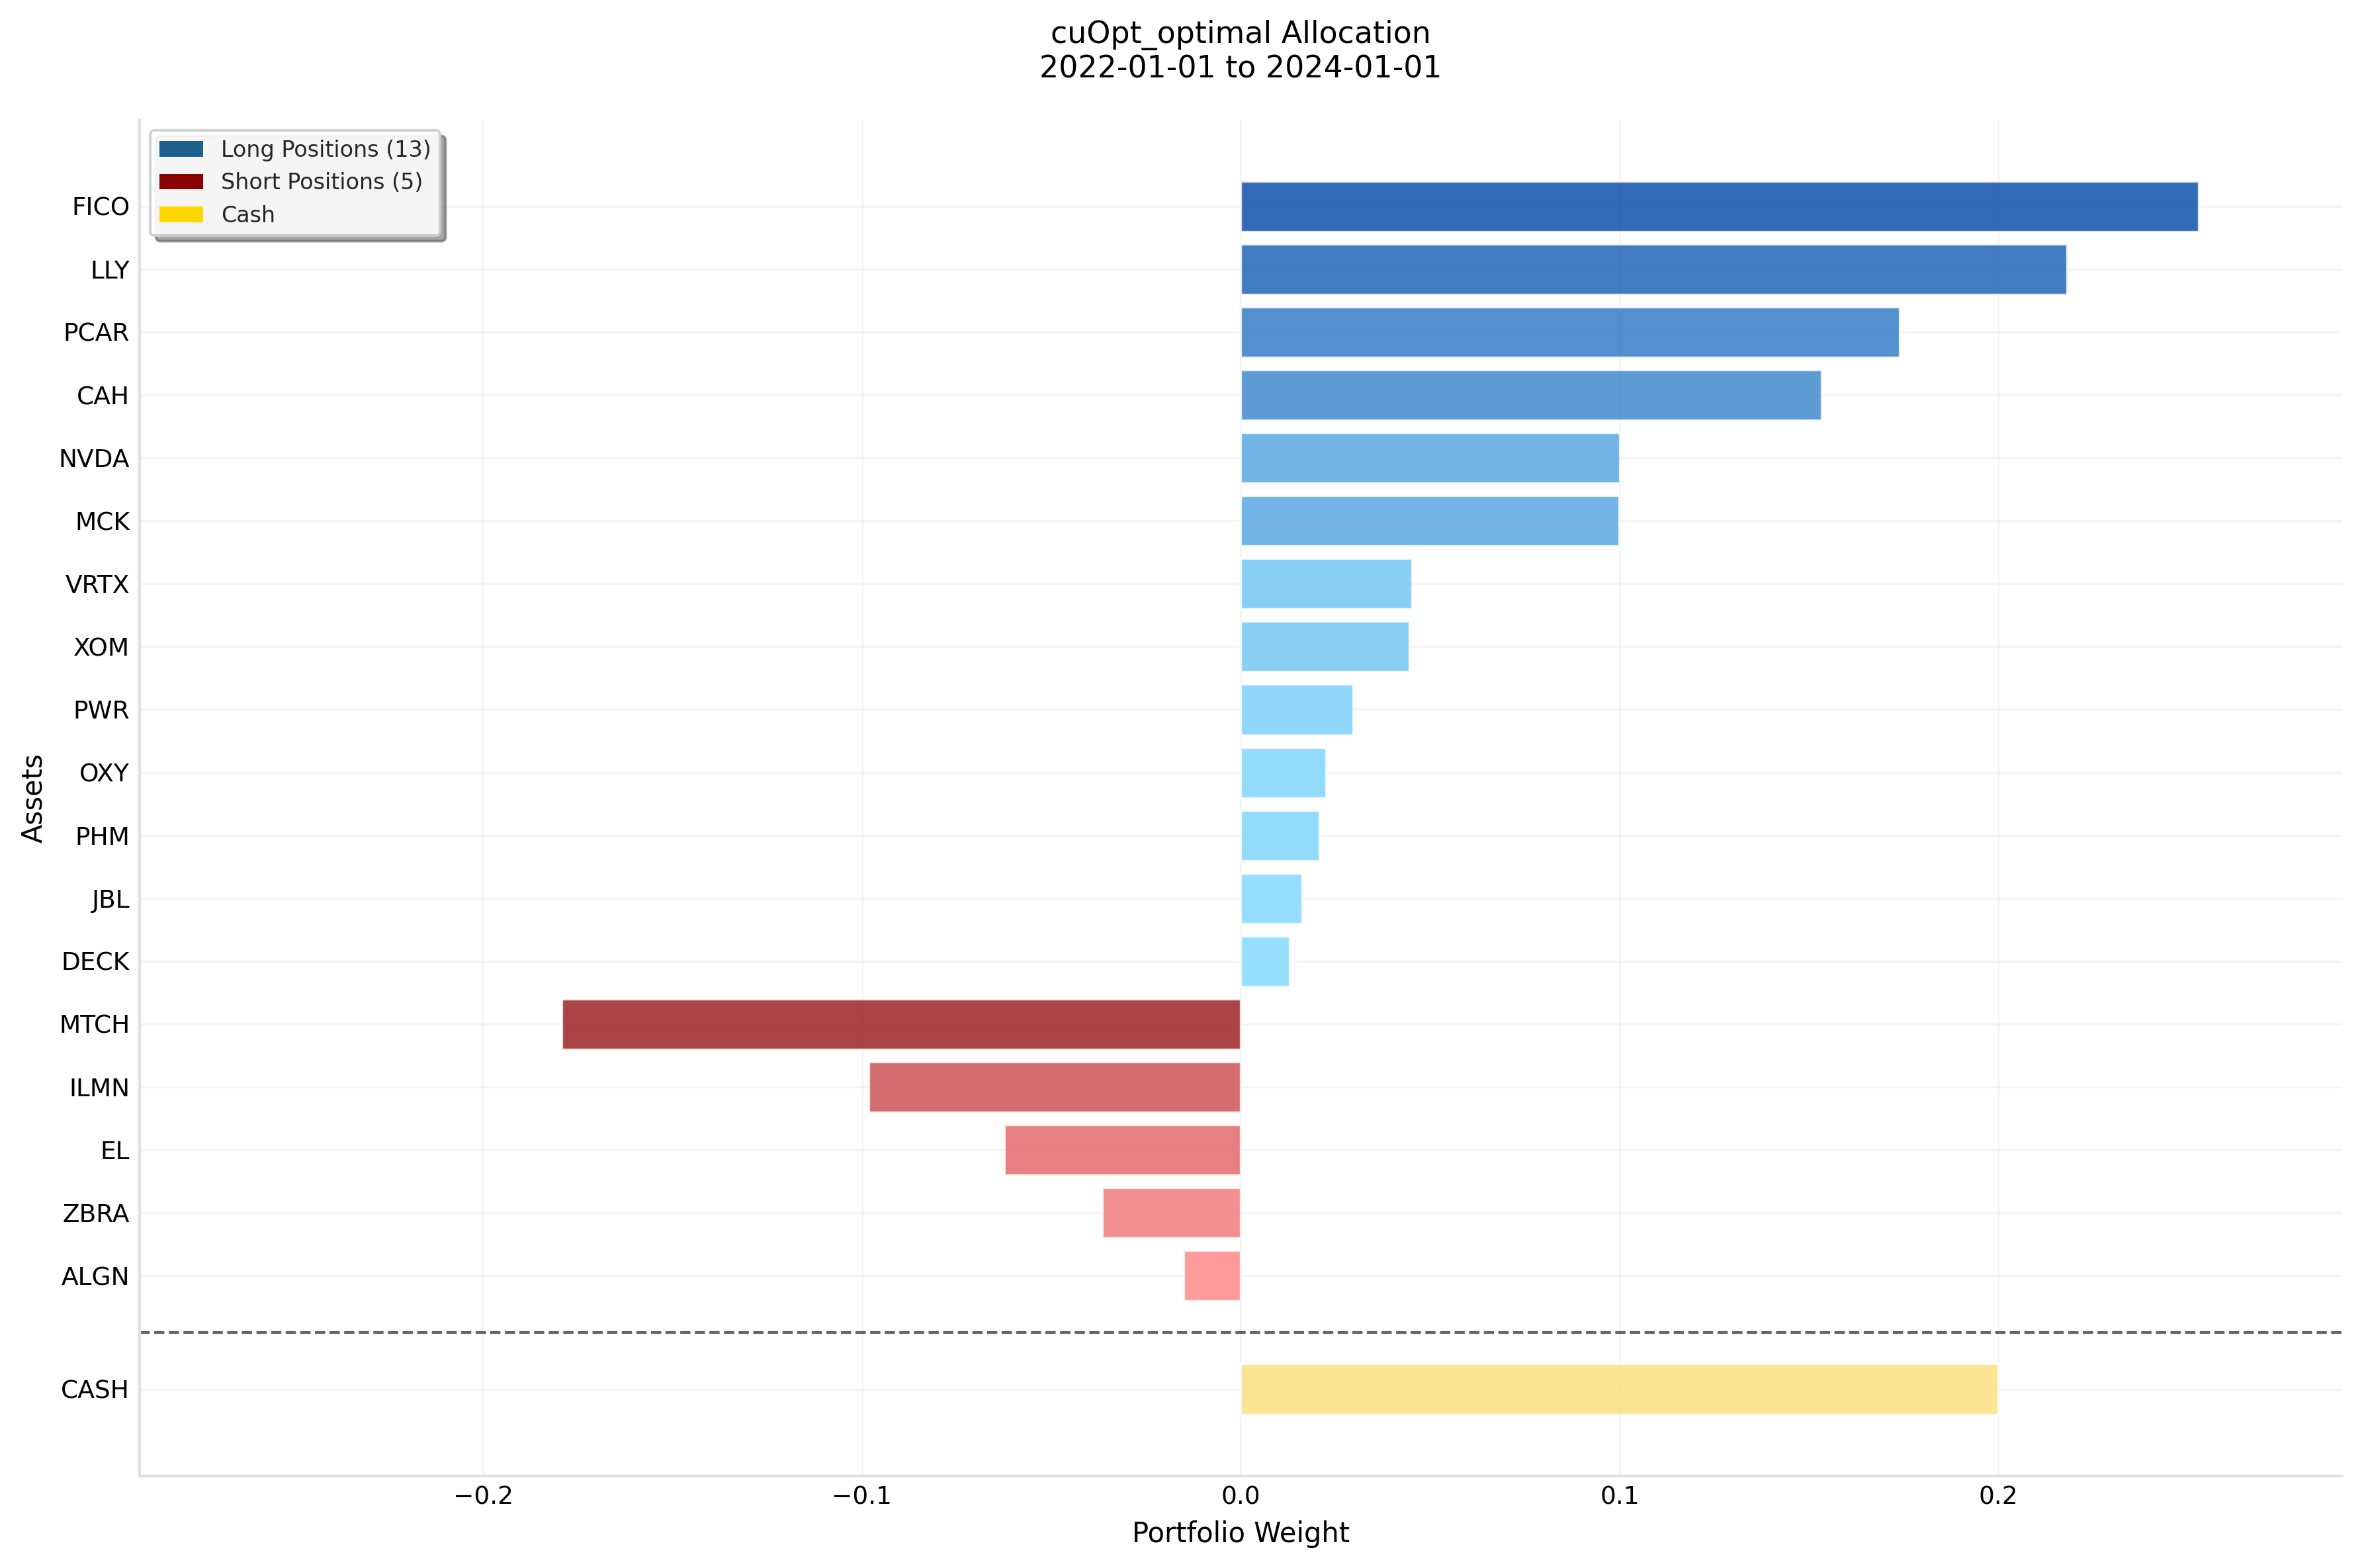

In [12]:
# Plot the optimized portfolio
ax = gpu_portfolio.plot_portfolio(show_plot=True, min_percentage=1)


### 5.2 Portfolio Statistics


In [14]:
# Get portfolio weights
weights = gpu_portfolio.weights

# Calculate portfolio statistics
expected_return = np.dot(returns_dict['mean'], weights)
portfolio_variance = weights @ returns_dict['covariance'] @ weights
portfolio_std = np.sqrt(portfolio_variance)
sharpe_ratio = expected_return / portfolio_std if portfolio_std > 0 else 0

print("Portfolio Statistics:")
print(f"  Expected Return: {expected_return:.4%}")
print(f"  Volatility (Std): {portfolio_std:.4%}")
print(f"  Variance: {portfolio_variance:.6f}")
print(f"  Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"  Cash Allocation: {gpu_portfolio.cash:.2%}")
print(f"  Leverage: {np.sum(np.abs(weights)):.4f}")
print(f"  Number of positions: {np.sum(np.abs(weights) > 0.001)}")


Portfolio Statistics:
  Expected Return: 0.2597%
  Volatility (Std): 1.1799%
  Variance: 0.000139
  Sharpe Ratio: 0.2202
  Cash Allocation: 20.00%
  Leverage: 1.5987
  Number of positions: 21


In [3]:
# CVaR parameters for regime comparison
regime_comparison_mean_variance_params = MeanVarianceParameters(
    w_min={"NVDA": 0.1, "others": -0.3},  # Min weights (allows shorting)
    w_max={"NVDA": 0.6, "others": 0.4},   # Max weights per asset
    c_min=0.0,                             # Minimum cash allocation
    c_max=0.2,                             # Maximum cash allocation
    L_tar=1.6,                             # Leverage constraint
    T_tar=None,                            # No turnover constraint
    risk_aversion=1.0,                     # Risk aversion level
    var_limit=None,                        # No hard variance limit
)

# User inputs for regime comparison
regime_comparison_dataset_name = "sp500"
regime_comparison_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)

# Prepare output directory and file name
regime_comparison_output_folder = "../results/regime_results"
os.makedirs(regime_comparison_output_folder, exist_ok=True)
regime_comparison_results_csv_path = os.path.join(
    regime_comparison_output_folder,
    f"both_results_{regime_comparison_dataset_name}_mean_variance.csv"
)

# Regime settings (customize as needed)
regime_comparison_selected_dict = {
    "pre_crisis"                  : ("2005-01-01", "2007-10-01"),
    "crisis"                      : ("2007-10-01", "2009-04-01"),
    # "post_crisis"                 : ("2009-06-30", "2014-06-30"),
    # "oil_price_crash"             : ("2014-06-01", "2016-03-01"),
    # "FAANG_surge"                 : ("2015-01-01", "2021-01-01"),
    # "covid"                       : ("2020-01-01", "2023-01-01"),
    # "recent"                      : ("2022-01-01", "2024-07-01")
}

# List of solvers to compare - any supported solver on CVXPY can be used.
solver_settings_list = [
    {"solver": cp.CLARABEL, "verbose": False, "tol_gap_abs": 1e-4, "tol_gap_rel": 1e-4, "tol_feas": 1e-4}, 
    {"solver":cp.CUOPT, "verbose": False, "solver_method": "PDLP", "optimality": 1e-4}
]

regime_comparison_dataset_path = f"../data/stock_data/{regime_comparison_dataset_name}.csv"

# Run CPU vs. GPU comparison across selected regimes
regime_comparison_results_df = utils.optimize_market_regimes(
    input_file_name=regime_comparison_dataset_path,
    returns_compute_settings=regime_comparison_returns_compute_settings,
    all_regimes=regime_comparison_selected_dict,
    params=regime_comparison_mean_variance_params,
    solver_settings_list=solver_settings_list,
    results_csv_file_name=regime_comparison_results_csv_path
)


Processing Regime: pre_crisis

--- Testing Solver: CLARABEL ---

MEAN-VARIANCE OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              pre_crisis
Time Period:         2005-01-01 to 2007-10-01
Assets:              392

PERFORMANCE METRICS
------------------------------
Expected Return:     0.004145 (0.4145%)
Variance:            0.000834
Std Deviation:       0.028876
Objective Value:     -0.004050

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.0020 seconds
CVXPY API Overhead:  0.0088 seconds
Solve Time:          0.1971 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2005-01-01 to 2007-10-01

LONG POSITIONS (4 assets)
-------------------------
MNST        0.400 ( 40.00%)
ISRG        0.400 ( 39.96%)
ILMN        0.398 ( 39.79%)
NVDA        0.100 ( 10.01%)
Total Long    1.298 (129.76%)

SHORT POSIT

In [ ]:
# Plot long-only portfolio
ax = long_only_portfolio.plot_portfolio(show_plot=True, min_percentage=1)


---

## Summary

In this notebook, we demonstrated:

1. **Mean-Variance Optimization** - The classic Markowitz portfolio optimization framework
2. **Data Preprocessing** - Loading price data and computing returns/covariance
3. **Constraint Specification** - Setting weight bounds, leverage, and other constraints
4. **GPU Acceleration** - Using cuOpt for fast quadratic program solving
5. **Results Analysis** - Evaluating portfolio performance metrics

### Key Differences from CVaR Optimization

| Aspect | Mean-Variance | CVaR |
|--------|---------------|------|
| Risk Measure | Variance (symmetric) | Tail risk (asymmetric) |
| Problem Type | QP (Quadratic) | LP (Linear) |
| Data Needed | Mean + Covariance | Scenarios |
| Distribution | Assumes normal | Distribution-free |
